
# Datathon Final Notebook 

Grafiklerden çıkan ana kararlar:

- `uyku_oncesi_kafein_mg` ve `sekerleme_suresi_dk` dağılımları sıfırda yoğunlaşıyor. Bu yüzden `kafein_tuketimi_yok` ve `sekerleme_yok` bayrakları eklendi.

- Korelasyon grafiğinde hedef değişkenle en güçlü ilişkiler `stres_skoru`, `rem_yuzdesi`, `gunluk_calisma_saati`, `derin_uyku_yuzdesi`, `gecelik_uyanma_sayisi` ve `uykuya_dalma_suresi_dk` tarafında. Bu yüzden uyku kalitesi, zihinsel yük ve uyku bölünmesi özellikleri korundu.

- Kategorik grafiklerde `ulke` sütununda İngilizce/Türkçe karışımı değerler görülüyor. Bu yüzden ülke isimleri normalize edildi. ( Spain : İspanya vb. durumlar)

- Önceki notebookta train/test birleştirildikten sonra hedef sütununun random doldurulması ve preprocessing'in modele tam yansımaması riski vardı. Bu sürümde hedef değişken asla doldurulmaz; preprocessing doğrudan `X` ve `test_X` üzerine uygulanır.

Ana çıktı dosyası:

`submission_best_notebook_oof_blend.csv`

Yedek dosya:

`submission_best_single_seed_3407.csv`

## 1. Kütüphaneler

In [1]:

import os
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


## 2. Ayarlar

In [2]:

# Kaggle ve lokal kullanım için otomatik dosya yolu bulma
POSSIBLE_DIRS = [
    Path('/kaggle/input/competitions/yzta-2026-datathon'),
    Path('/kaggle/input/yzta-2026-datathon'),
    Path('.'),
    Path('/mnt/data')
]

DATA_DIR = None
for p in POSSIBLE_DIRS:
    if (p / 'train.csv').exists() and (p / 'test_x.csv').exists():
        DATA_DIR = p
        break

if DATA_DIR is None:
    raise FileNotFoundError('train.csv ve test_x.csv bulunamadı. Dosyaları notebook ile aynı klasöre koy.')

TRAIN_PATH = DATA_DIR / 'train.csv'
TEST_PATH = DATA_DIR / 'test_x.csv'
SAMPLE_PATH = DATA_DIR / 'sample_submission.csv'

TARGET = 'bilissel_performans_skoru'
ID_COL = 'id'

CAT_COLS = [
    'cinsiyet',
    'meslek',
    'ulke',
    'kronotip',
    'ruh_sagligi_durumu',
    'mevsim',
    'gun_tipi'
]

# Ayarlar
# True = tüm sayısal sütunları 0-1 aralığına alır.
USE_MINMAX_SCALING = False

# True =  sayısal NaN'ları median ile doldurur.
FILL_NUMERIC_NAN = False

# Seedler
SEEDS = [42, 2024, 3407]
N_SPLITS = 5

print('DATA_DIR:', DATA_DIR)


DATA_DIR: .


## 3. Veri Yükleme

In [3]:

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print('Train shape:', train_df.shape)
print('Test shape :', test_df.shape)

display(train_df.head())
display(test_df.head())


Train shape: (56000, 24)
Test shape : (24000, 23)


,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,uyku_oncesi_kafein_mg,uyku_oncesi_ekran_suresi_dk,gunluk_adim_sayisi,sekerleme_suresi_dk,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi,bilissel_performans_skoru
0,1,34,Erkek,Saglik Personeli,31.470103,Cin,14.431210,14.645436,27,7,0.0,97,7184,0,9.922976,10.045274,Sabah insani,Anksiyete ve depresyon,78,18.962436,-0.074140,Sonbahar-Kis,Hafta ici,0.136441
1,2,32,Kadin,Muhendis,30.981394,Amerika,21.771870,27.220360,20,4,4.0,180,5057,1,6.626400,6.319245,Gece insani,Saglikli,76,21.225666,0.942672,Sonbahar-Kis,Hafta ici,5.848312
2,3,39,Erkek,Ev Hanimi,21.533898,Spain,18.178857,25.530104,33,7,148.0,23,10816,70,6.093566,3.824463,Notr,Depresyon,66,18.482409,1.239886,Ilkbahar-Yaz,Hafta sonu,6.828276
3,4,40,Kadin,Egitimci,23.310749,Yeni Zelanda,21.438151,15.891188,21,2,0.0,180,5238,115,3.168185,4.597316,Gece insani,Saglikli,60,21.862235,0.727695,Sonbahar-Kis,Hafta sonu,8.144649
4,5,36,Kadin,NaN,NaN,Portekiz,25.468018,16.356738,21,8,100.0,145,4042,0,7.198574,3.189120,Notr,Anksiyete ve depresyon,74,19.223195,-0.223402,Sonbahar-Kis,Hafta ici,0.431423


,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,uyku_oncesi_kafein_mg,uyku_oncesi_ekran_suresi_dk,gunluk_adim_sayisi,sekerleme_suresi_dk,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi
0,1,42,Erkek,Saglik Personeli,29.728724,Ingiltere,21.691917,23.990157,21,5,4.0,20,10225,0,6.349196,9.419561,Gece insani,Depresyon,82,21.627129,1.716161,Ilkbahar-Yaz,Hafta sonu
1,2,26,Kadin,Serbest Calisan,32.865996,Cin,22.090624,18.231963,34,5,0.0,30,5600,0,NaN,8.574199,Gece insani,Saglikli,66,27.835934,1.482283,Ilkbahar-Yaz,Hafta ici
2,3,21,Erkek,Lojistik Calisani,24.438264,Cin,19.488438,16.695363,17,4,0.0,13,3261,52,6.715192,10.519017,Notr,Depresyon,63,20.252258,1.981034,Sonbahar-Kis,Hafta ici
3,4,61,Kadin,Saglik Personeli,23.275057,Cin,26.831092,21.762040,29,2,82.0,62,6156,2,5.633400,9.814789,Gece insani,Saglikli,71,17.680971,0.589750,Sonbahar-Kis,Hafta ici
4,5,26,Kadin,Saglik Personeli,24.815531,Ingiltere,16.271522,18.153212,15,4,0.0,50,13265,0,7.953794,9.308398,Sabah insani,Saglikli,53,23.698979,0.622211,Ilkbahar-Yaz,Hafta ici


## 4. EDA — Eksik Değerler

,train_missing,test_missing
kronotip,1968,832
meslek,1378,622
ruh_sagligi_durumu,1096,504
stres_skoru,1715,765
uyku_oncesi_kafein_mg,1463,697
vucut_kitle_indeksi,1752,648


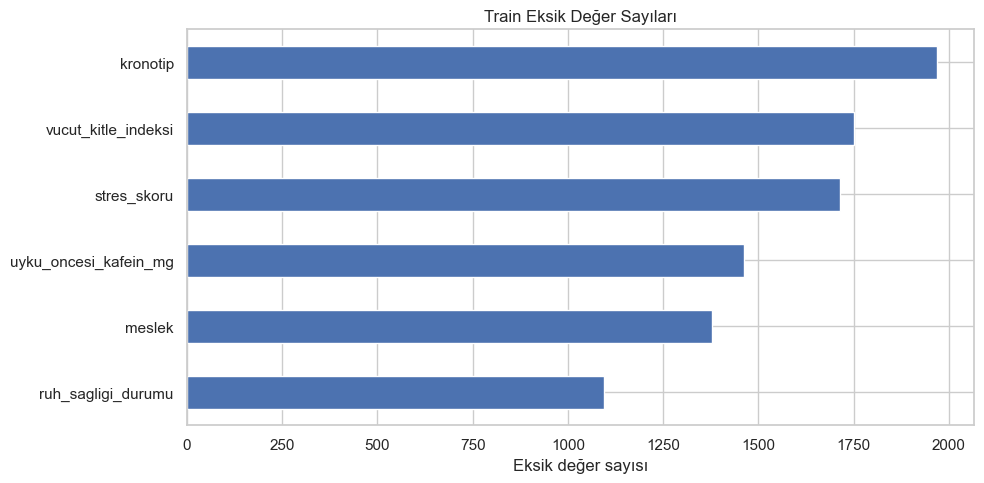

In [4]:

missing_train = train_df.isna().sum().sort_values(ascending=False)
missing_test = test_df.isna().sum().sort_values(ascending=False)

missing_table = pd.DataFrame({
    'train_missing': missing_train,
    'test_missing': missing_test
}).fillna(0).astype(int)

missing_table = missing_table[missing_table.sum(axis=1) > 0]
display(missing_table)

plt.figure(figsize=(10, 5))
missing_table.sort_values('train_missing', ascending=True)['train_missing'].plot(kind='barh')
plt.title('Train Eksik Değer Sayıları')
plt.xlabel('Eksik değer sayısı')
plt.tight_layout()
plt.show()



**Yorum:** Eksikler özellikle `kronotip`, `vucut_kitle_indeksi`, `stres_skoru`, `uyku_oncesi_kafein_mg`, `meslek` ve `ruh_sagligi_durumu` sütunlarında yoğunlaşıyor. Kategorik eksikleri ayrı bir sınıf olarak tutuyoruz; sayısal eksikler için CatBoost'un kendi NaN yönetimini korumak varsayılan olarak daha iyi sonuç verdi.


## 5. EDA — Hedef Değişken Dağılımı

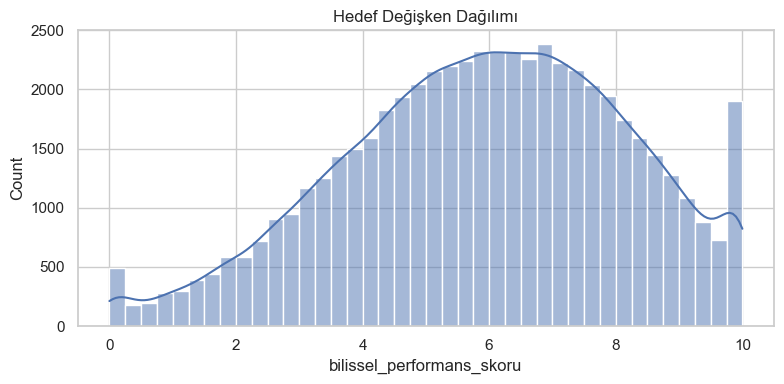

count    56000.000000
mean         5.913096
std          2.231759
min          0.000000
25%          4.397431
50%          6.032249
75%          7.574980
max         10.000000
Name: bilissel_performans_skoru, dtype: float64


In [5]:

plt.figure(figsize=(8, 4))
sns.histplot(train_df[TARGET], bins=40, kde=True)
plt.title('Hedef Değişken Dağılımı')
plt.xlabel(TARGET)
plt.tight_layout()
plt.show()

print(train_df[TARGET].describe())


## 6. EDA — Sayısal Değişken Histogramları

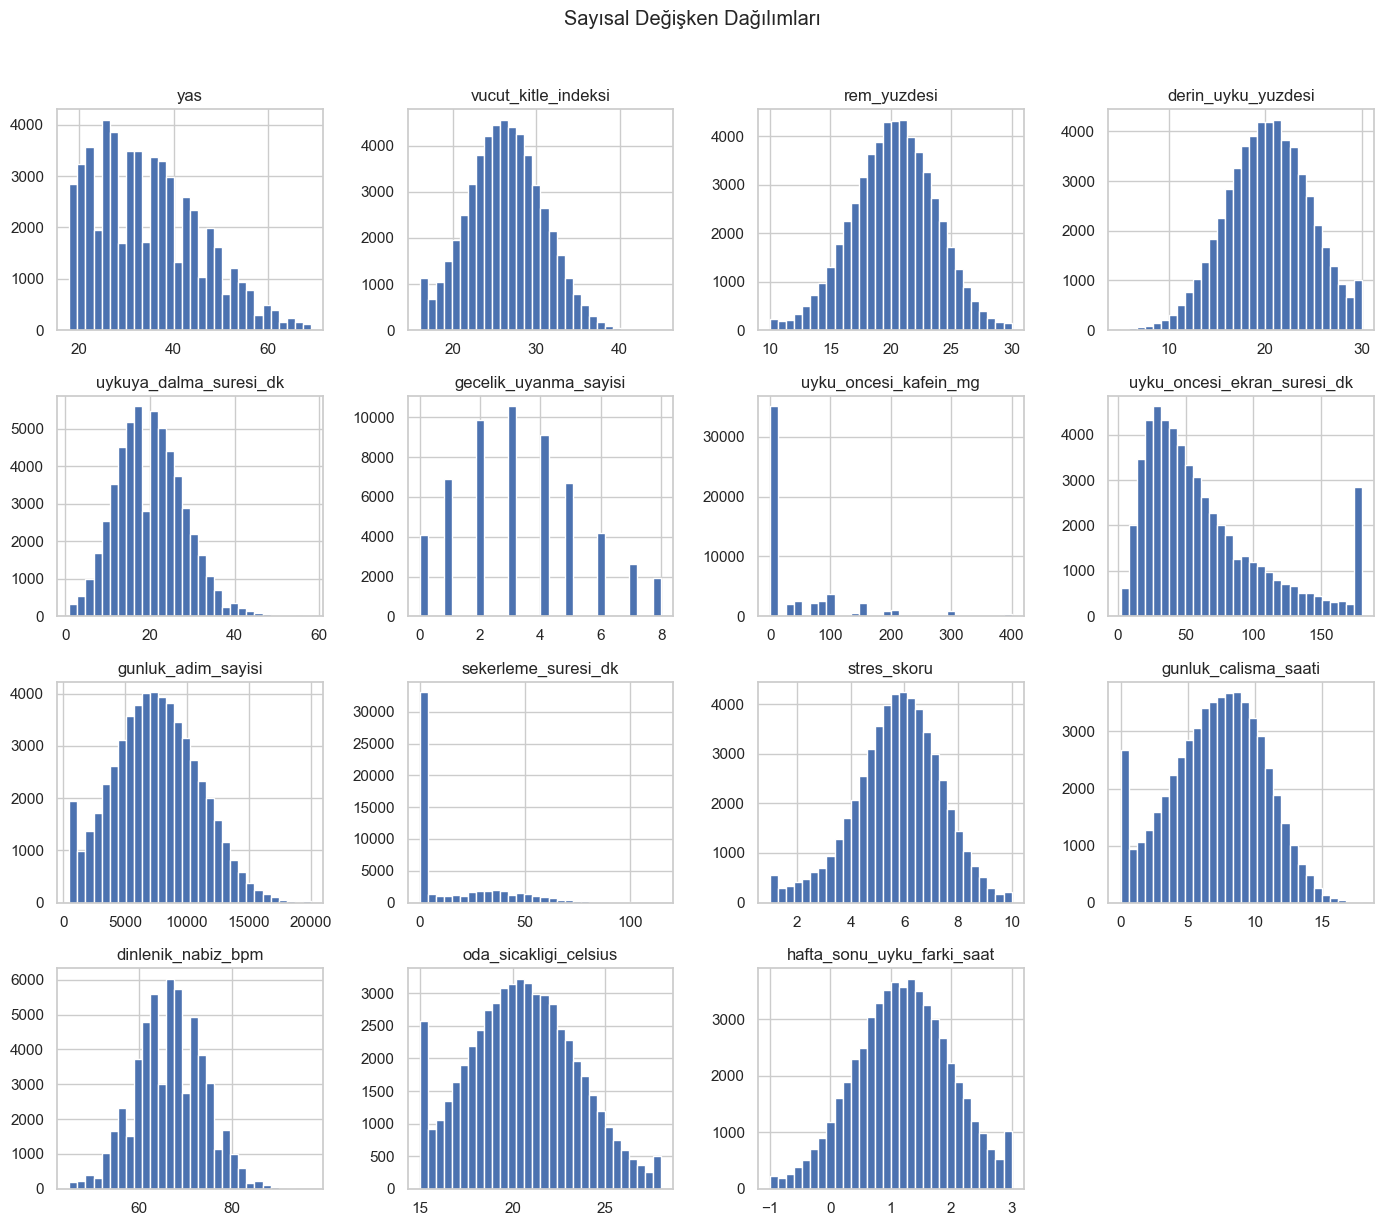

In [6]:

num_cols_original = [c for c in train_df.select_dtypes(exclude='object').columns if c not in [ID_COL, TARGET]]

train_df[num_cols_original].hist(figsize=(14, 12), bins=30)
plt.suptitle('Sayısal Değişken Dağılımları', y=1.02)
plt.tight_layout()
plt.show()



**Yorum:** `uyku_oncesi_kafein_mg` ve `sekerleme_suresi_dk` değişkenleri sıfırda yoğunlaşıyor. Bu yüzden bu değişkenleri sadece sayısal değer olarak değil, ayrıca "hiç tüketim/yok" bayrağıyla da temsil ediyoruz.


## 7. EDA — Kategorik Değişken Dağılımları

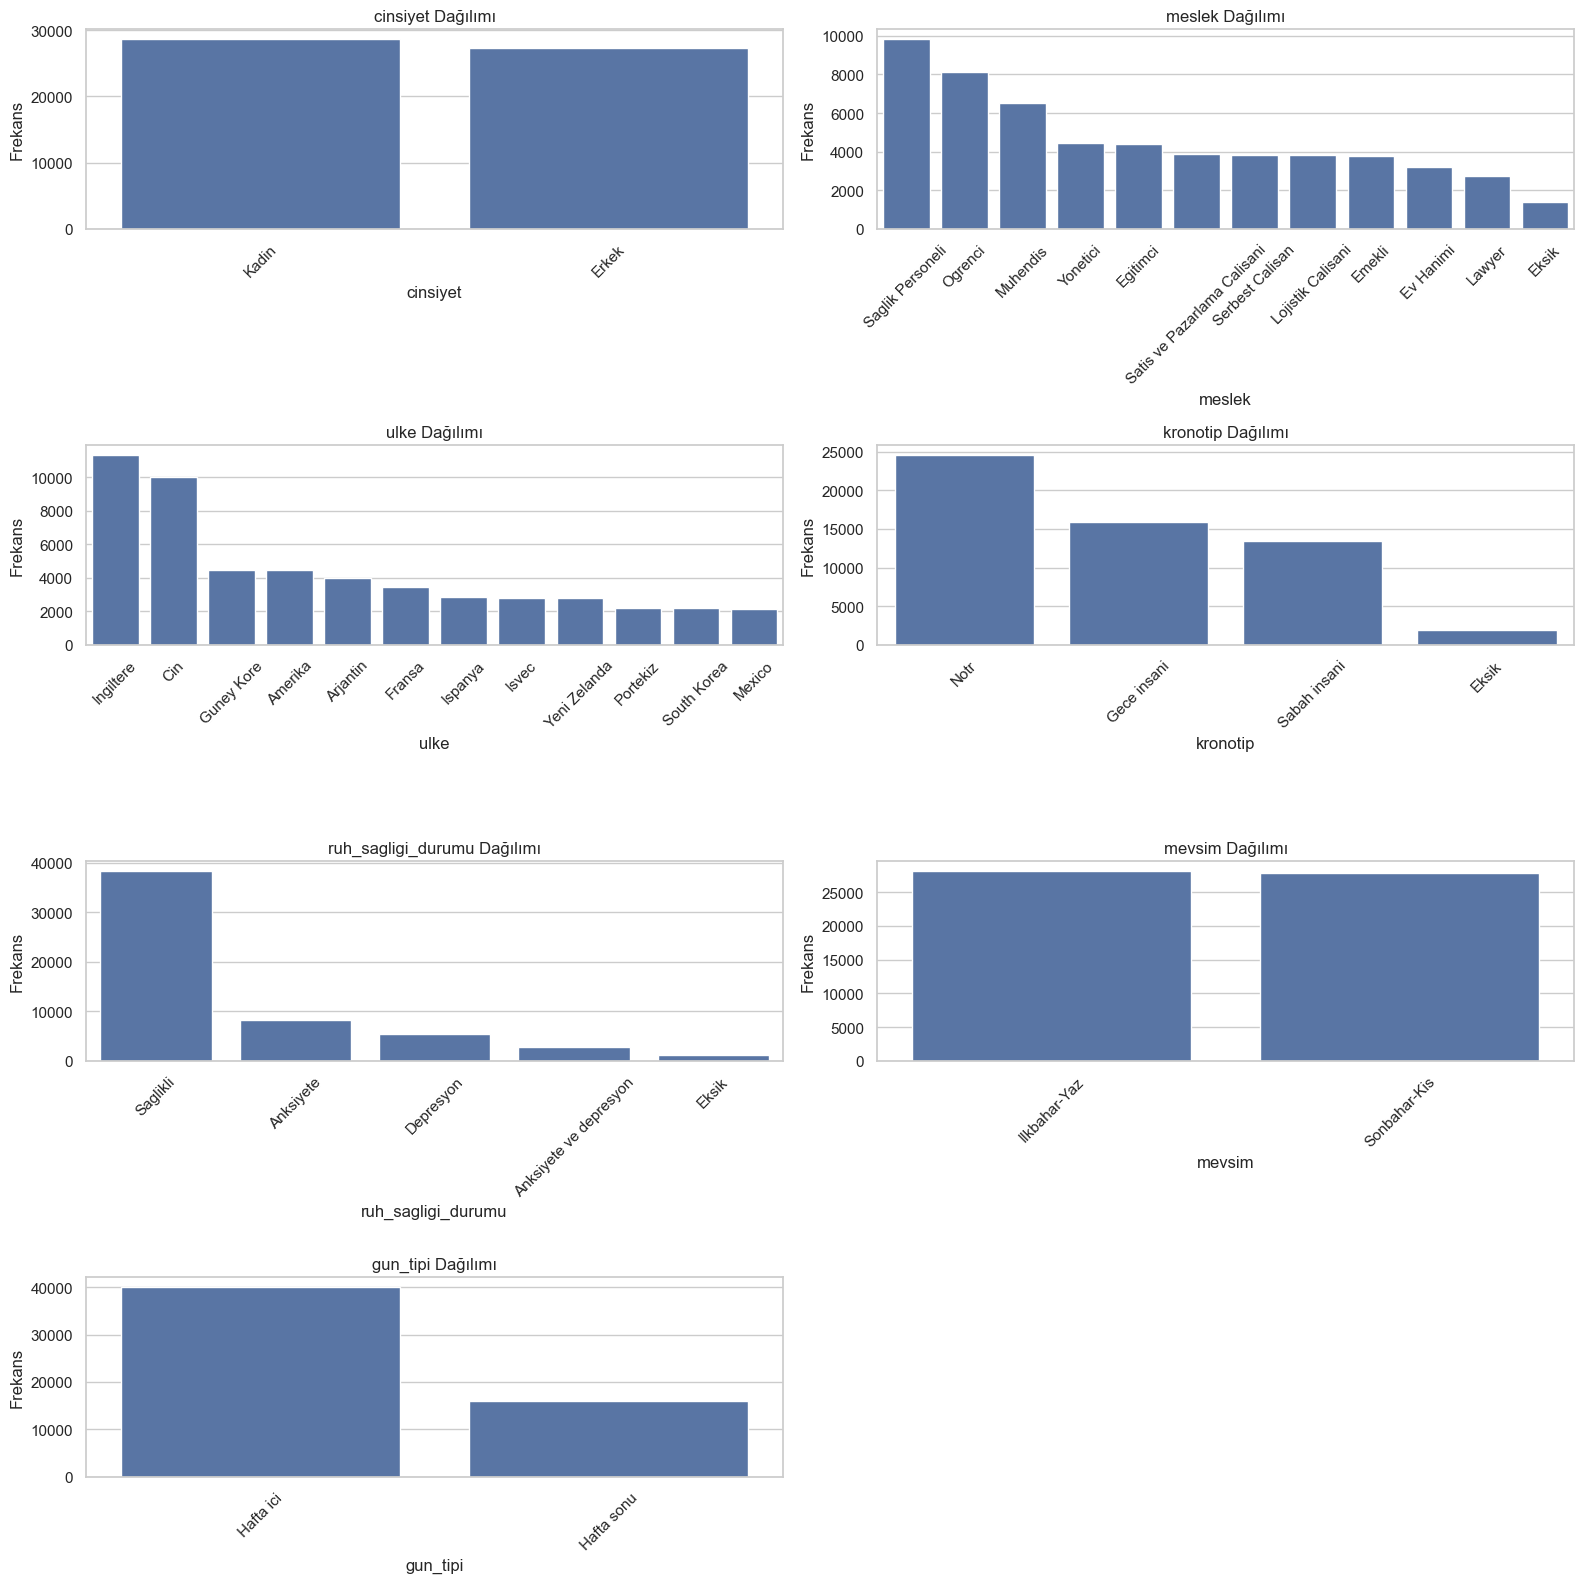

,unique_count,missing_count,missing_ratio,most_common,most_common_count
cinsiyet,2,0,0.000000,Kadin,28676
meslek,12,1378,0.024607,Saglik Personeli,9842
ulke,15,0,0.000000,Ingiltere,11324
kronotip,4,1968,0.035143,Notr,24594
ruh_sagligi_durumu,5,1096,0.019571,Saglikli,38365
mevsim,2,0,0.000000,Ilkbahar-Yaz,28143
gun_tipi,2,0,0.000000,Hafta ici,40052


In [7]:
cat_cols_available = [c for c in CAT_COLS if c in train_df.columns]

if len(cat_cols_available) == 0:
    print("Kategorik sütun bulunamadı.")
else:
    # Grafik için ayrı kopya oluşturuyoruz.
    # Asıl train_df bozulmasın diye burada sadece plot_df kullanıyoruz.
    plot_df = train_df.copy()

    for col in cat_cols_available:
        plot_df[col] = (
            plot_df[col]
            .fillna("Eksik")
            .astype(str)
            .str.strip()
        )

    n_cols = 2
    n_rows = int(np.ceil(len(cat_cols_available) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))

    if n_rows == 1:
        axes = np.array(axes).reshape(-1)

    axes = axes.flatten()

    for i, col in enumerate(cat_cols_available):
        order = plot_df[col].value_counts(dropna=False).head(12).index.tolist()

        sns.countplot(
            ax=axes[i],
            data=plot_df,
            x=col,
            order=order
        )

        axes[i].set_title(f"{col} Dağılımı")
        axes[i].tick_params(axis="x", rotation=45)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frekans")

    for j in range(len(cat_cols_available), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

    cat_summary = pd.DataFrame({
        "unique_count": plot_df[cat_cols_available].nunique(dropna=False),
        "missing_count": train_df[cat_cols_available].isna().sum(),
        "missing_ratio": train_df[cat_cols_available].isna().mean(),
        "most_common": plot_df[cat_cols_available].apply(
            lambda x: x.value_counts(dropna=False).index[0]
            if len(x.value_counts(dropna=False)) > 0 else np.nan
        ),
        "most_common_count": plot_df[cat_cols_available].apply(
            lambda x: x.value_counts(dropna=False).iloc[0]
            if len(x.value_counts(dropna=False)) > 0 else 0
        )
    })

    display(cat_summary)


**Yorum:** `ulke` sütununda `South Korea / Guney Kore`, `Spain / Ispanya`, `Sweden / Isvec` gibi aynı anlamı taşıyan farklı yazımlar var. Modelin aynı ülkeyi iki farklı kategori gibi görmesini azaltmak için normalize ediyoruz.


## 8. EDA — Korelasyon

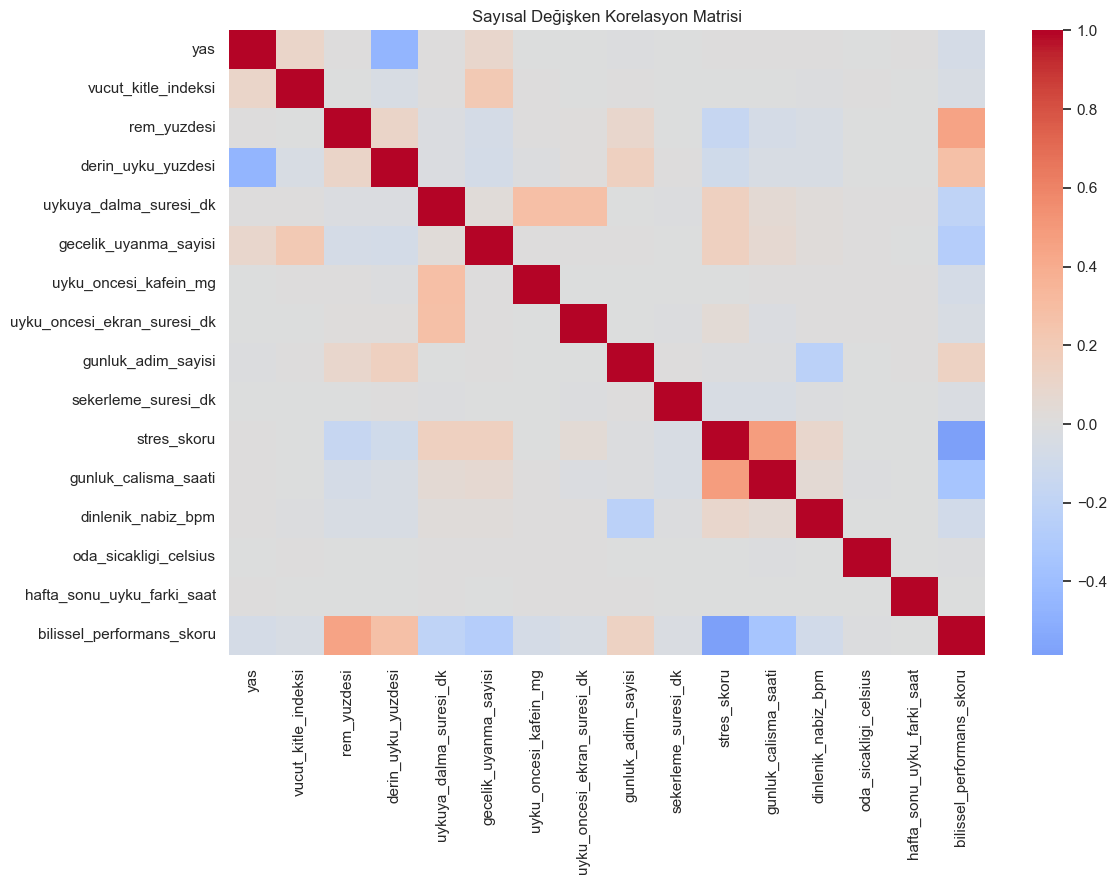

,target_corr
stres_skoru,-0.586676
rem_yuzdesi,0.442999
gunluk_calisma_saati,-0.342112
derin_uyku_yuzdesi,0.280006
gecelik_uyanma_sayisi,-0.270349
uykuya_dalma_suresi_dk,-0.207349
gunluk_adim_sayisi,0.134042
dinlenik_nabiz_bpm,-0.089389
yas,-0.070659
uyku_oncesi_kafein_mg,-0.062387


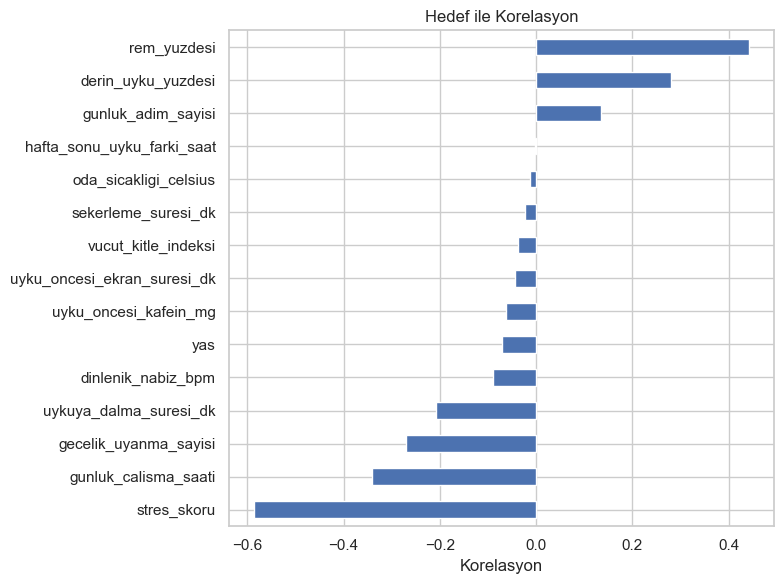

In [8]:

corr = train_df[num_cols_original + [TARGET]].corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Sayısal Değişken Korelasyon Matrisi')
plt.tight_layout()
plt.show()

target_corr = corr[TARGET].drop(TARGET).sort_values(key=lambda s: s.abs(), ascending=False)
display(target_corr.to_frame('target_corr'))

plt.figure(figsize=(8, 6))
target_corr.sort_values().plot(kind='barh')
plt.title('Hedef ile Korelasyon')
plt.xlabel('Korelasyon')
plt.tight_layout()
plt.show()



**Yorum:** En belirgin sinyaller stres, REM uyku yüzdesi, çalışma saati, derin uyku, gece uyanma sayısı ve uykuya dalma süresi etrafında. Bu yüzden feature engineering kısmında uyku kalitesi, uyku bölünmesi ve zihinsel yük değişkenleri korunuyor.


## 9. Yardımcı Fonksiyonlar — Temizleme ve Feature Engineering

In [9]:

def normalize_country_value(value):
    if pd.isna(value):
        return 'Bilinmiyor'

    value = str(value).strip()

    country_map = {
        'South Korea': 'Guney Kore',
        'Korea, South': 'Guney Kore',
        'Güney Kore': 'Guney Kore',
        'Guney Kore': 'Guney Kore',

        'Spain': 'Ispanya',
        'España': 'Ispanya',
        'İspanya': 'Ispanya',
        'Ispanya': 'Ispanya',

        'Sweden': 'Isvec',
        'İsveç': 'Isvec',
        'Isvec': 'Isvec',

        'Netherlands': 'Hollanda',
        'Hollanda': 'Hollanda',

        'Mexico': 'Meksika',
        'Meksika': 'Meksika',

        'United States': 'Amerika',
        'USA': 'Amerika',
        'US': 'Amerika',
        'America': 'Amerika',
        'Amerika': 'Amerika',

        'Turkey': 'Turkiye',
        'Türkiye': 'Turkiye',
        'Turkiye': 'Turkiye',

        'United Kingdom': 'Ingiltere',
        'UK': 'Ingiltere',
        'England': 'Ingiltere',
        'İngiltere': 'Ingiltere',
        'Ingiltere': 'Ingiltere',
    }

    return country_map.get(value, value)


def add_features(df):
    df = df.copy()


    df['toplam_kaliteli_uyku'] = df['rem_yuzdesi'] + df['derin_uyku_yuzdesi']
    df['uyku_bolunme_siddeti'] = (df['gecelik_uyanma_sayisi'] + 1) * df['uykuya_dalma_suresi_dk']
    df['zihinsel_yuk_indeksi'] = df['gunluk_calisma_saati'] * df['stres_skoru']
    df['uyku_oncesi_stres_tetikleyici'] = df['uyku_oncesi_kafein_mg'] + (df['uyku_oncesi_ekran_suresi_dk'] * 2)
    df['adim_basina_vucut_yuku'] = df['gunluk_adim_sayisi'] / (df['vucut_kitle_indeksi'] + 1)
    df['hafta_sonu_telafi_uykusu'] = df['hafta_sonu_uyku_farki_saat'] * df['toplam_kaliteli_uyku']

    # Grafiklerden gelen güvenli bayrak özellikleri:
    df['kafein_tuketimi_yok'] = (df['uyku_oncesi_kafein_mg'].fillna(-1) == 0).astype(int)
    df['sekerleme_yok'] = (df['sekerleme_suresi_dk'].fillna(-1) == 0).astype(int)
    df['ekran_suresi_cok_yuksek'] = (df['uyku_oncesi_ekran_suresi_dk'].fillna(-1) >= 170).astype(int)
    df['gece_uyanma_yok'] = (df['gecelik_uyanma_sayisi'].fillna(-1) == 0).astype(int)
    df['yuksek_stres'] = (df['stres_skoru'].fillna(-1) >= 8).astype(int)

    # Eksik değer bayrakları:
    for col in ['vucut_kitle_indeksi', 'stres_skoru', 'uyku_oncesi_kafein_mg']:
        if col in df.columns:
            df[f'{col}_eksik_mi'] = df[col].isna().astype(int)

    return df


def prepare_model_data(train_df, test_df):
    y = train_df[TARGET].copy()
    X = train_df.drop([ID_COL, TARGET], axis=1).copy()
    T = test_df.drop([ID_COL], axis=1).copy()
    test_ids = test_df[ID_COL].copy()

    # Ülke normalizasyonu
    if 'ulke' in X.columns:
        X['ulke'] = X['ulke'].apply(normalize_country_value)
        T['ulke'] = T['ulke'].apply(normalize_country_value)

    # Kategorik eksikleri = Bilinmiyor sınıfına al
    for col in CAT_COLS:
        X[col] = X[col].fillna('Bilinmiyor').astype(str).str.strip()
        T[col] = T[col].fillna('Bilinmiyor').astype(str).str.strip()

    # Feature engineering
    X = add_features(X)
    T = add_features(T)

    # Sonsuz değerleri NaN yap
    num_cols = [c for c in X.columns if c not in CAT_COLS]
    X[num_cols] = X[num_cols].replace([np.inf, -np.inf], np.nan)
    T[num_cols] = T[num_cols].replace([np.inf, -np.inf], np.nan)

    if FILL_NUMERIC_NAN:
        for col in num_cols:
            median_value = X[col].median()
            X[col] = X[col].fillna(median_value)
            T[col] = T[col].fillna(median_value)

    if USE_MINMAX_SCALING:
        # CatBoost için varsayılan False.
        # NaN varsa MinMaxScaler çalışmaz; bu yüzden ölçekleme açılırsa numeric NaN da dolduruldu:
        for col in num_cols:
            median_value = X[col].median()
            X[col] = X[col].fillna(median_value)
            T[col] = T[col].fillna(median_value)

        scaler = MinMaxScaler()
        X[num_cols] = scaler.fit_transform(X[num_cols])
        T[num_cols] = scaler.transform(T[num_cols])
        X[num_cols] = X[num_cols].clip(0, 1)
        T[num_cols] = T[num_cols].clip(0, 1)

    return X, y, T, test_ids, num_cols


## 10. Model Verisini Hazırla

In [10]:

X, y, test_X, test_ids, num_cols = prepare_model_data(train_df, test_df)

print('Model train shape:', X.shape)
print('Model test shape :', test_X.shape)
print('Train NaN toplam :', X.isna().sum().sum())
print('Test NaN toplam  :', test_X.isna().sum().sum())
print('Sayısal sütun sayısı:', len(num_cols))

display(X.head())


Model train shape: (56000, 36)
Model test shape : (24000, 36)
Train NaN toplam : 9860
Test NaN toplam  : 4220
Sayısal sütun sayısı: 29


,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,uyku_oncesi_kafein_mg,uyku_oncesi_ekran_suresi_dk,gunluk_adim_sayisi,sekerleme_suresi_dk,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi,toplam_kaliteli_uyku,uyku_bolunme_siddeti,zihinsel_yuk_indeksi,uyku_oncesi_stres_tetikleyici,adim_basina_vucut_yuku,hafta_sonu_telafi_uykusu,kafein_tuketimi_yok,sekerleme_yok,ekran_suresi_cok_yuksek,gece_uyanma_yok,yuksek_stres,vucut_kitle_indeksi_eksik_mi,stres_skoru_eksik_mi,uyku_oncesi_kafein_mg_eksik_mi
0,34,Erkek,Saglik Personeli,31.470103,Cin,14.431210,14.645436,27,7,0.0,97,7184,0,9.922976,10.045274,Sabah insani,Anksiyete ve depresyon,78,18.962436,-0.074140,Sonbahar-Kis,Hafta ici,29.076646,216,99.679011,194.0,221.249684,-2.155739,1,1,0,0,1,0,0,0
1,32,Kadin,Muhendis,30.981394,Amerika,21.771870,27.220360,20,4,4.0,180,5057,1,6.626400,6.319245,Gece insani,Saglikli,76,21.225666,0.942672,Sonbahar-Kis,Hafta ici,48.992230,100,41.873844,364.0,158.123188,46.183618,0,0,1,0,0,0,0,0
2,39,Erkek,Ev Hanimi,21.533898,Ispanya,18.178857,25.530104,33,7,148.0,23,10816,70,6.093566,3.824463,Notr,Depresyon,66,18.482409,1.239886,Ilkbahar-Yaz,Hafta sonu,43.708961,264,23.304616,194.0,479.987977,54.194117,0,0,0,0,0,0,0,0
3,40,Kadin,Egitimci,23.310749,Yeni Zelanda,21.438151,15.891188,21,2,0.0,180,5238,115,3.168185,4.597316,Gece insani,Saglikli,60,21.862235,0.727695,Sonbahar-Kis,Hafta sonu,37.329339,63,14.565145,360.0,215.460248,27.164358,1,0,1,0,0,0,0,0
4,36,Kadin,Bilinmiyor,NaN,Portekiz,25.468018,16.356738,21,8,100.0,145,4042,0,7.198574,3.189120,Notr,Anksiyete ve depresyon,74,19.223195,-0.223402,Sonbahar-Kis,Hafta ici,41.824756,189,22.957118,390.0,NaN,-9.343736,0,1,0,0,0,1,0,0


## 11. CatBoost Parametreleri

In [11]:

base_params = {
    'iterations': 1210,
    'learning_rate': 0.02058,
    'depth': 7,
    'l2_leaf_reg': 6.296,
    'random_strength': 2.433,
    'bagging_temperature': 0.298,
    'cat_features': CAT_COLS,
    'eval_metric': 'RMSE',
    'verbose': False,
    'allow_writing_files': False
}

base_params


{'iterations': 1210,
 'learning_rate': 0.02058,
 'depth': 7,
 'l2_leaf_reg': 6.296,
 'random_strength': 2.433,
 'bagging_temperature': 0.298,
 'cat_features': ['cinsiyet',
  'meslek',
  'ulke',
  'kronotip',
  'ruh_sagligi_durumu',
  'mevsim',
  'gun_tipi'],
 'eval_metric': 'RMSE',
 'verbose': False,
 'allow_writing_files': False}

## 12. Eğitim Fonksiyonu

In [12]:

def rmse_score(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5


def fit_catboost_seed(X, y, test_X, seed):
    print('' + '=' * 70)
    print(f'CatBoost eğitiliyor | Seed: {seed}')
    print('=' * 70)

    params = base_params.copy()
    params['random_seed'] = seed

    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)

    oof = np.zeros(len(X))
    test_pred = np.zeros(len(test_X))
    fold_scores = []

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X), 1):
        X_train, X_val = X.iloc[tr_idx].copy(), X.iloc[val_idx].copy()
        y_train, y_val = y.iloc[tr_idx].copy(), y.iloc[val_idx].copy()

        model = CatBoostRegressor(**params)
        model.fit(
            X_train,
            y_train,
            eval_set=(X_val, y_val),
            early_stopping_rounds=50,
            use_best_model=True
        )

        val_pred = model.predict(X_val)
        fold_test_pred = model.predict(test_X)

        oof[val_idx] = val_pred
        test_pred += fold_test_pred / N_SPLITS

        fold_rmse = rmse_score(y_val, val_pred)
        fold_scores.append(fold_rmse)
        print(f'Seed {seed} | Fold {fold} RMSE: {fold_rmse:.5f}')

    oof_clipped = np.clip(oof, 0, 10)
    test_pred_clipped = np.clip(test_pred, 0, 10)

    seed_rmse = rmse_score(y, oof_clipped)
    seed_mae = mean_absolute_error(y, oof_clipped)
    seed_r2 = r2_score(y, oof_clipped)

    print(f'Seed {seed} Ortalama Fold RMSE: {np.mean(fold_scores):.5f}')
    print(f'Seed {seed} OOF RMSE          : {seed_rmse:.5f}')
    print(f'Seed {seed} OOF MAE           : {seed_mae:.5f}')
    print(f'Seed {seed} OOF R2            : {seed_r2:.5f}')

    return oof_clipped, test_pred_clipped, seed_rmse, fold_scores


## 13. 3 Seed Eğitim

In [13]:

oof_dict = {}
test_pred_dict = {}
score_dict = {}
fold_score_dict = {}

for seed in SEEDS:
    oof_seed, test_seed, score_seed, fold_scores = fit_catboost_seed(X, y, test_X, seed)
    oof_dict[seed] = oof_seed
    test_pred_dict[seed] = test_seed
    score_dict[seed] = score_seed
    fold_score_dict[seed] = fold_scores

score_report = pd.DataFrame({
    'seed': list(score_dict.keys()),
    'oof_rmse': list(score_dict.values())
}).sort_values('oof_rmse')

display(score_report)


CatBoost eğitiliyor | Seed: 42
Seed 42 | Fold 1 RMSE: 1.22383
Seed 42 | Fold 2 RMSE: 1.21880
Seed 42 | Fold 3 RMSE: 1.20340
Seed 42 | Fold 4 RMSE: 1.20997
Seed 42 | Fold 5 RMSE: 1.23324
Seed 42 Ortalama Fold RMSE: 1.21785
Seed 42 OOF RMSE          : 1.21781
Seed 42 OOF MAE           : 0.97239
Seed 42 OOF R2            : 0.70224
CatBoost eğitiliyor | Seed: 2024
Seed 2024 | Fold 1 RMSE: 1.22464
Seed 2024 | Fold 2 RMSE: 1.21605
Seed 2024 | Fold 3 RMSE: 1.23014
Seed 2024 | Fold 4 RMSE: 1.20508
Seed 2024 | Fold 5 RMSE: 1.21048
Seed 2024 Ortalama Fold RMSE: 1.21728
Seed 2024 OOF RMSE          : 1.21724
Seed 2024 OOF MAE           : 0.97229
Seed 2024 OOF R2            : 0.70252
CatBoost eğitiliyor | Seed: 3407
Seed 3407 | Fold 1 RMSE: 1.20849
Seed 3407 | Fold 2 RMSE: 1.22506
Seed 3407 | Fold 3 RMSE: 1.22061
Seed 3407 | Fold 4 RMSE: 1.21544
Seed 3407 | Fold 5 RMSE: 1.21523
Seed 3407 Ortalama Fold RMSE: 1.21697
Seed 3407 OOF RMSE          : 1.21690
Seed 3407 OOF MAE           : 0.97179
Seed 340

,seed,oof_rmse
2,3407,1.216905
1,2024,1.217239
0,42,1.217810


## 14. OOF’ye Göre En İyi Seed Blend Ağırlığını Bul

In [14]:

seed_list = list(SEEDS)

oof_matrix = np.column_stack([oof_dict[s] for s in seed_list])
test_matrix = np.column_stack([test_pred_dict[s] for s in seed_list])

best_rmse = 999
best_weights = None

# 0.01 hassasiyetle ağırlık arama
for w0 in np.arange(0, 1.001, 0.01):
    for w1 in np.arange(0, 1.001 - w0, 0.01):
        w2 = 1 - w0 - w1
        weights = np.array([w0, w1, w2])
        blend_oof = np.clip(oof_matrix @ weights, 0, 10)
        score = rmse_score(y, blend_oof)
        if score < best_rmse:
            best_rmse = score
            best_weights = weights

print('En iyi OOF blend RMSE:', round(best_rmse, 6))
for seed, weight in zip(seed_list, best_weights):
    print(f'Seed {seed}: {weight:.2f}')

best_blend_oof = np.clip(oof_matrix @ best_weights, 0, 10)
best_blend_test = np.clip(test_matrix @ best_weights, 0, 10)

print('Blend MAE:', mean_absolute_error(y, best_blend_oof))
print('Blend R2 :', r2_score(y, best_blend_oof))


En iyi OOF blend RMSE: 1.216125
Seed 42: 0.20
Seed 2024: 0.35
Seed 3407: 0.45
Blend MAE: 0.9712558468051874
Blend R2 : 0.7030593742665049


## 15. Submission Dosyalarını Oluştur

In [15]:

# Ana Dosya: OOF ağırlıklı seed blend
submission_blend = pd.DataFrame({
    ID_COL: test_ids,
    TARGET: best_blend_test
})
submission_blend.to_csv('submission_best_notebook_oof_blend.csv', index=False)

print('Ana submission oluşturuldu: submission_best_notebook_oof_blend.csv')
display(submission_blend.head())

# En iyi tek seed dosyası da yedek olarak kayıt ediliyor
best_seed = min(score_dict, key=score_dict.get)
submission_best_seed = pd.DataFrame({
    ID_COL: test_ids,
    TARGET: test_pred_dict[best_seed]
})
submission_best_seed.to_csv(f'submission_best_single_seed_{best_seed}.csv', index=False)

print(f'Yedek submission oluşturuldu: submission_best_single_seed_{best_seed}.csv')


Ana submission oluşturuldu: submission_best_notebook_oof_blend.csv


,id,bilissel_performans_skoru
0,1,6.032166
1,2,6.671724
2,3,2.998697
3,4,7.191510
4,5,3.738948


Yedek submission oluşturuldu: submission_best_single_seed_3407.csv


## 16. Rapor Dosyaları

In [16]:

# Fold skor raporu
fold_rows = []
for seed, scores in fold_score_dict.items():
    for i, score in enumerate(scores, 1):
        fold_rows.append({'seed': seed, 'fold': i, 'rmse': score})

fold_report = pd.DataFrame(fold_rows)
fold_report.to_csv('fold_report_best_notebook.csv', index=False)

# Genel skor raporu
blend_row = pd.DataFrame({
    'seed': ['best_oof_blend'],
    'oof_rmse': [best_rmse]
})
score_report_final = pd.concat([score_report, blend_row], ignore_index=True)
score_report_final.to_csv('score_report_best_notebook.csv', index=False)

# Preprocess raporu
preprocess_report = pd.DataFrame({
    'column': num_cols,
    'train_missing_after': X[num_cols].isna().sum().values,
    'test_missing_after': test_X[num_cols].isna().sum().values,
    'train_min': X[num_cols].min().values,
    'train_max': X[num_cols].max().values,
    'test_min': test_X[num_cols].min().values,
    'test_max': test_X[num_cols].max().values
})
preprocess_report.to_csv('preprocess_report_best_notebook.csv', index=False)

print('Raporlar oluşturuldu:')
print('- fold_report_best_notebook.csv')
print('- score_report_best_notebook.csv')
print('- preprocess_report_best_notebook.csv')

display(score_report_final)


Raporlar oluşturuldu:
- fold_report_best_notebook.csv
- score_report_best_notebook.csv
- preprocess_report_best_notebook.csv


,seed,oof_rmse
0,3407,1.216905
1,2024,1.217239
2,42,1.217810
3,best_oof_blend,1.216125
